# Lab 03 : Policy Network with Global Reward - demo

This notebook explores a variation of the Policy Gradient method by implementing a Policy Network with Global Rewards to solve the CartPole-v0 environment. It focuses on using a relative reward signal to train a stochastic policy.

Global Reward Strategy: Unlike local reward methods, this approach uses a baseline policy network for comparison. The loss is calculated by comparing the current policy's total episode reward against the reward achieved by the baseline model, which helps reduce variance and stabilize learning.

Policy Architecture: Utilizes a neural network (Policy_NN) with a hidden layer (128 or 256 units) that outputs action probabilities via a softmax function.

Training Loop:

Rollouts: Collects trajectories from both the current policy and the baseline policy.

Baseline Updates: Periodically evaluates the current policy against the baseline; if the current policy performs significantly better, it replaces the baseline.

Performance: The model successfully reaches the reward threshold (~400 steps) within approximately 50 epochs.


In [2]:
import torch
import torch.nn as nn
torch.manual_seed(torch.randint(10000,())) # random seed for pythorch random generator
import time
import numpy as np
import os
import pickle
import gymnasium as gym 
import matplotlib
import matplotlib.pyplot as plt
from IPython import display
from collections import namedtuple
import random
from itertools import count


# Dataset

In [4]:
#Initialize the environment with the same seed/initialization value
env = gym.make('CartPole-v1')

# Reset the environment
state, info = env.reset() # initial state from the environment
print('init state:',state)

# Rollout one episode until it finishes 
for t in count():  
    action = torch.LongTensor(1).random_(0,2).item() # randomly generated action=a in {0,1}
    state, reward, terminated, truncated, info = env.step(action) # receive next state=s' and reward=r
    done = terminated or truncated
    print('t=',t, 'action=',action, 'state=',np.array_str(state, precision=5), 'reward=',reward, 'done=',done )
    if done:
        break


init state: [-0.04898993 -0.01066289  0.00885291  0.00715959]
t= 0 action= 0 state= [-0.0492  -0.20591  0.009    0.30262] reward= 1.0 done= False
t= 1 action= 0 state= [-0.05332 -0.40116  0.01505  0.59813] reward= 1.0 done= False
t= 2 action= 1 state= [-0.06134 -0.20625  0.02701  0.31022] reward= 1.0 done= False
t= 3 action= 0 state= [-0.06547 -0.40175  0.03322  0.6113 ] reward= 1.0 done= False
t= 4 action= 0 state= [-0.0735  -0.59732  0.04544  0.91426] reward= 1.0 done= False
t= 5 action= 0 state= [-0.08545 -0.79302  0.06373  1.22087] reward= 1.0 done= False
t= 6 action= 0 state= [-0.10131 -0.98891  0.08814  1.53282] reward= 1.0 done= False
t= 7 action= 1 state= [-0.12109 -0.79495  0.1188   1.2689 ] reward= 1.0 done= False
t= 8 action= 1 state= [-0.13699 -0.60153  0.14418  1.01565] reward= 1.0 done= False
t= 9 action= 0 state= [-0.14902 -0.79825  0.16449  1.34991] reward= 1.0 done= False
t= 10 action= 0 state= [-0.16498 -0.99501  0.19149  1.68921] reward= 1.0 done= False
t= 11 action=

# Define the policy network

In [6]:
# class of policy network
class Policy_NN(nn.Module): 
    
    def __init__(self, net_parameters):
        super(Policy_NN, self).__init__()
        input_dim = net_parameters['input_dim']
        hidden_dim = net_parameters['hidden_dim']
        output_dim = net_parameters['output_dim']
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        actions_score = self.fc2(x)
        actions_prob = torch.softmax(actions_score, dim=1)
        return actions_prob
    
    def select_action(self, state): # select action w/ policy network
        probs = self.forward(state) # probability of action a in state s
        bernoulli_sampling = torch.distributions.Categorical(probs) 
        action = bernoulli_sampling.sample() # sample action a with Bernoulli sampling
        log_prob = bernoulli_sampling.log_prob(action) # compute log prob of selected action
        action = action.item()
        return action, log_prob
    
    def loss(self, batch_rewards, batch_log_probs, batch_rewards_baseline):
        nb_episodes_per_batch = len(batch_rewards)
        batch_episode_rewards = torch.Tensor(batch_rewards)
        batch_episode_rewards_baseline = torch.Tensor(batch_rewards_baseline)
        batch_episode_rewards -= batch_episode_rewards_baseline # compare current model w.r.t. baseline model
        batch_policy_losses = []
        for episode in range(nb_episodes_per_batch):
            episode_reward = batch_episode_rewards[episode]
            episode_log_probs = torch.stack(batch_log_probs[episode])
            policy_loss = - episode_log_probs.sum() * episode_reward
            batch_policy_losses.append(policy_loss)
        loss = torch.stack(batch_policy_losses).mean()
        return loss
        

        
# class of rollout episodes
def rollout_batch_episodes(env, opt_parameters, policy_net):
    # storage structure of all episodes (w/ different lengths):
    #   batch_rewards =         [    - ,       -      , ...,    -   ]
    #   batch_log_probs =       [ [- - -] , [- - - -] , ... , [- -] ]
    #   batch_episode_lengths = [    - ,       -      , ...,    -   ]
    nb_episodes_per_batch = opt_parameters['nb_episodes_per_batch']
    env_seeds = opt_parameters['env_seed']
    batch_rewards = []
    batch_log_probs = []
    batch_episode_lengths = []
    for episode in range(nb_episodes_per_batch):
        rewards = []
        log_probs = []
        state, info = env.reset(seed=int(env_seeds[episode].item())) # start with random seed
        for t in range(1000): # rollout one episode
            state_pytorch = torch.from_numpy(state).float().unsqueeze(0) # state=s
            action, log_prob = policy_net.select_action(state_pytorch) # select action=a from state=s
            state, reward, terminated, truncated, info = env.step(action)  # receive next state=s' and reward=r
            done = terminated or truncated
            rewards.append(reward)
            log_probs.append(log_prob)
            if done:
                batch_episode_lengths.append(t)
                batch_rewards.append(t)
                batch_log_probs.append(log_probs)
                break
    return batch_rewards, batch_log_probs, batch_episode_lengths

        
    
# network parameters
net_parameters = {}
net_parameters['input_dim'] = 4
net_parameters['hidden_dim'] = 128
net_parameters['output_dim'] = 2

# instantiate network
policy_net = Policy_NN(net_parameters)
print(policy_net)
baseline_policy_net = Policy_NN(net_parameters)
baseline_policy_net.load_state_dict(policy_net.state_dict())
baseline_policy_net = baseline_policy_net.eval()
print(baseline_policy_net)

# optimization parameters
opt_parameters = {}
opt_parameters['nb_episodes_per_batch'] = 3
opt_parameters['env_seed'] = torch.LongTensor(opt_parameters['nb_episodes_per_batch']).random_(1,10000)

env = gym.make('CartPole-v0')

batch_rewards, batch_log_probs, batch_episode_lengths = rollout_batch_episodes(env, opt_parameters, policy_net)
#print('batch_rewards:',batch_rewards)
#print('batch_log_probs:',batch_log_probs)
print('batch_episode_lengths:',batch_episode_lengths)


Policy_NN(
  (fc1): Linear(in_features=4, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
)
Policy_NN(
  (fc1): Linear(in_features=4, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
)
batch_episode_lengths: [19, 15, 72]


# Test forward pass

In [7]:
# optimization parameters
opt_parameters = {}
opt_parameters['lr'] = 0.001
opt_parameters['nb_episodes_per_batch'] = 3
opt_parameters['nb_batches_per_epoch'] = 10
opt_parameters['env_seed'] = torch.LongTensor(opt_parameters['nb_episodes_per_batch']).random_(1,10000)
opt_parameters['gamma'] = 0.99

batch_rewards, batch_log_probs, batch_episode_lengths = rollout_batch_episodes(env, opt_parameters, policy_net)
print('batch_episode_lengths:',batch_episode_lengths)

batch_rewards_baseline, batch_log_probs_baseline, batch_episode_lengths_baseline = rollout_batch_episodes(env, opt_parameters, policy_net)
print('batch_episode_lengths:',batch_episode_lengths_baseline)


batch_episode_lengths: [14, 29, 23]
batch_episode_lengths: [18, 10, 61]


# Test backward pass

In [8]:
# Loss
loss = policy_net.loss(batch_rewards, batch_log_probs, batch_rewards_baseline)
print('loss:',loss)

# Backward pass
lr = opt_parameters['lr']
optimizer = torch.optim.Adam(policy_net.parameters(), lr=lr)
optimizer.zero_grad()
loss.backward()
optimizer.step()


loss: tensor(-91.8462, grad_fn=<MeanBackward0>)


# Train one epoch

In [11]:
def train_one_epoch(env, policy_net, baseline_policy_net, opt_parameters):
    """
    train one epoch
    """    
    policy_net.train()
    baseline_policy_net.eval()
    epoch_loss = 0
    nb_data = 0
    epoch_episode_length = 0
    epoch_episode_lengths = []
    nb_batches_per_epoch = opt_parameters['nb_batches_per_epoch']
    for iter in range(nb_batches_per_epoch):
        opt_parameters['env_seed'] = torch.LongTensor(opt_parameters['nb_episodes_per_batch']).random_(1,10000)
        batch_rewards, batch_log_probs, batch_episode_lengths = rollout_batch_episodes(env, opt_parameters, policy_net)
        batch_rewards_baseline, batch_log_probs_baseline, batch_episode_lengths_baseline = rollout_batch_episodes(env, opt_parameters, baseline_policy_net)
        loss = policy_net.loss(batch_rewards, batch_log_probs, batch_rewards_baseline)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.detach().item()
        nb_data += len(batch_episode_lengths)
        epoch_episode_length += torch.tensor(batch_episode_lengths).float().sum()
        epoch_episode_lengths.append(epoch_episode_length)
    epoch_loss /= nb_data
    epoch_episode_length /= nb_data
    return epoch_loss, epoch_episode_length, epoch_episode_lengths



# Train NN

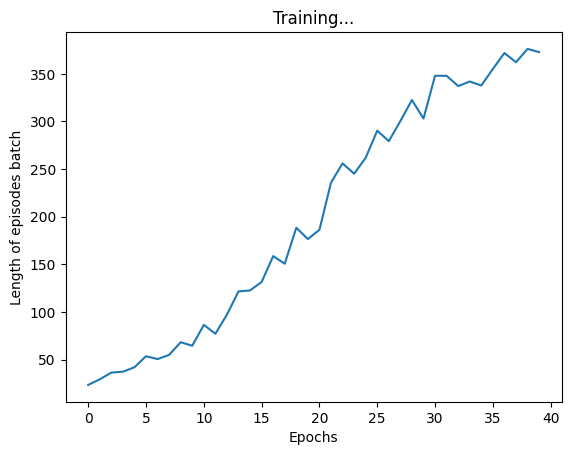

Training done.
Last episode length is 393.4200134277344, epoch is 41


In [12]:
# network parameters
net_parameters = {}
net_parameters['input_dim'] = 4
net_parameters['hidden_dim'] = 256
net_parameters['output_dim'] = 2

# instantiate network
policy_net = Policy_NN(net_parameters)
print(policy_net)
baseline_policy_net = Policy_NN(net_parameters)
baseline_policy_net = baseline_policy_net.eval()
print(baseline_policy_net)

# optimization parameters
opt_parameters = {}
opt_parameters['lr'] = 0.0005
opt_parameters['nb_episodes_per_batch'] = 5
opt_parameters['nb_batches_per_epoch'] = 10

optimizer = torch.optim.Adam(policy_net.parameters(), lr=opt_parameters['lr'])

# select maximum episode length to learn
env = gym.make('CartPole-v1')
env._max_episode_steps = 400 # 200 400
env.spec.reward_threshold = 0.975* env._max_episode_steps
print('env._max_episode_steps',env._max_episode_steps)

# train loop
all_epoch_lengths = []
start = time.time()
num_epochs = 500
for epoch in range(num_epochs): 
    
    # train one epoch
    epoch_train_loss, epoch_episode_length, epoch_episode_lengths = \
        train_one_epoch(env, policy_net, baseline_policy_net, opt_parameters)

    # update baseline if current policy better
    if epoch>0 and (not epoch%2):
        opt_parameters['env_seed'] = torch.LongTensor(10).random_(1,10000)
        _, _, batch_episode_lengths = rollout_batch_episodes(env, opt_parameters, policy_net)
        _, _, batch_episode_lengths_baseline = rollout_batch_episodes(env, opt_parameters, baseline_policy_net)
        if torch.Tensor(batch_episode_lengths).mean() > torch.Tensor(batch_episode_lengths_baseline).mean():
            if not (epoch+1)%10:
                print('UPDATE BASELINE - epoch:',epoch)
            baseline_policy_net.load_state_dict(policy_net.state_dict())
        else:
            if not (epoch+1)%10:
                print('NO UPDATE BASELINE - epoch:',epoch)
    
    # stop training when reward is high
    if epoch_episode_length > env.spec.reward_threshold:
        print('Training done.')
        print("Last episode length is {}, epoch is {}".
              format(epoch_episode_length, epoch))
        break

    # print intermediate info
    if not (epoch+1)%10:
        print('Epoch: {}, time: {:.4f}, train_loss: {:.4f}, episode_length: {:.4f}'.format(epoch, time.time()-start, epoch_train_loss, epoch_episode_length))
        print('           policy net eval: {:.4f}, baseline policy net eval: {:.4f}'.format(torch.Tensor(batch_episode_lengths).mean().item(), torch.Tensor(batch_episode_lengths_baseline).mean().item() ))
      
    # plot all epochs
    all_epoch_lengths.append(epoch_episode_length)
    if not (epoch+1)%10:
        if epoch<num_epochs:
            display.clear_output(wait=True)
        plt.figure(2)
        plt.title('Training...')
        plt.xlabel('Epochs')
        plt.ylabel('Length of episodes batch')
        plt.plot(torch.Tensor(all_epoch_lengths).numpy())
        plt.pause(0.001)


# Visualize

Finished at step 395


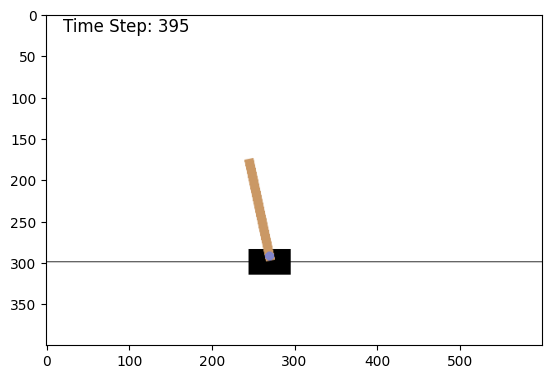

In [13]:
# For Google Colaboratory
import sys
if 'google.colab' in sys.modules:
    import gnwrapper
    env = gnwrapper.Monitor(gym.make('CartPole-v1', render_mode="rgb_array"), directory="./") 
    env._max_episode_steps = 5000
    # env._max_episode_steps = 100 # DEBUG
    state, _ = env.reset()
    for t in range(env._max_episode_steps):
        state_pytorch = torch.from_numpy(state).float().unsqueeze(0)
        action = Q_net.eval().select_action(state_pytorch, 0.0) # select action=a from state=s
        next_state, reward, terminated, truncated, info = env.step(action) # receive next state=s' and reward=r
        done = terminated or truncated
        # env.render() # no need this line with Monitor/gnwrapper; it records automatically
        if done:
            print(f"Episode finished at step {t}")
            break
    env.display()

# For Local Environment
else: 
    env = gym.make('CartPole-v1', render_mode="rgb_array")
    env._max_episode_steps = 5000
    # env._max_episode_steps = 100 # DEBUG
    state, info = env.reset() 
    img = plt.imshow(env.render()) # Setup the plot
    time_text = plt.text(20, 20, '', color='black', fontsize=12)
    for t in range(env._max_episode_steps):
        state_pytorch = torch.from_numpy(state).float().unsqueeze(0)
        action, _ = policy_net.eval().select_action(state_pytorch) # select action=a from state=s        
        state, reward, terminated, truncated, info = env.step(action) # receive next state=s' and reward=r
        done = terminated or truncated
        img.set_data(env.render()) 
        time_text.set_text(f'Time Step: {t}')
        display.display(plt.gcf())
        display.clear_output(wait=True)
        if done:
            break
        env.close()
    print(f"Finished at step {t}")

        